In [1]:
import os
print(os.getcwd())
import sys
sys.path.append("QuAlgorithms")
sys.path.append(".")
print(sys.path)
import numpy as np

from state_preparation import matrix_msob2
from qsiht_library import generate_binary_values
from qsiht_library import generate_and_shift_array
from qsiht_library import generalFastPath
from qft import qft
from qft import qft2
import qiskit 
from qiskit import QuantumCircuit
import numpy as np
import math
from medmnist import BreastMNIST
import warnings
warnings.filterwarnings("ignore")



c:\Users\mando\Downloads\QuAlgorithms\QuAlgorithms-master\qu_algorithms
['c:\\Users\\mando\\miniconda3\\envs\\qiskit\\python314.zip', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\DLLs', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit', '', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages\\win32', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages\\Pythonwin', 'QuAlgorithms', '.']


In [2]:
import math
import numpy as np
from qiskit import QuantumCircuit


# ============================================================
# CORE BUTTERFLY
# ============================================================

def butterfly(values):
    values = [float(v) for v in values]
    n = len(values)

    if n < 2:
        raise ValueError("Need at least 2 values.")
    if (n & (n - 1)) != 0:
        raise ValueError(f"Length must be a power of 2. Got {n}.")

    stages = []
    current = values[:]

    while len(current) > 1:
        pairs = []
        next_values = []

        for i in range(0, len(current), 2):
            j, k = current[i], current[i + 1]

            # ✅ FIXED
            angle_rad = -2 * math.atan2(k, j)

            new_val = math.sqrt(j**2 + k**2)

            pairs.append({
                "j": j,
                "k": k,
                "angle_rad": angle_rad,
                "newvalue": new_val
            })

            next_values.append(new_val)

        stages.append(pairs)
        current = next_values

    return {"stages": stages, "final": current[0]}





# ============================================================
# POSTORDER
# ============================================================

def butterfly_postorder_nodes(stages):
    """
    Returns nodes in postorder:
    left subtree, right subtree, parent

    Also returns stage/pair info so we know where each angle came from.
    """
    def walk(stage_idx, pair_idx):
        node = {
            "stage": stage_idx + 1,
            "pair": pair_idx,
            "angle_rad": stages[stage_idx][pair_idx]["angle_rad"]
        }

        if stage_idx == 0:
            return [node]

        left = walk(stage_idx - 1, 2 * pair_idx)
        right = walk(stage_idx - 1, 2 * pair_idx + 1)
        return left + right + [node]

    return walk(len(stages) - 1, 0)


# ============================================================
# BIT / QUBIT MAPPING
# Convention B:
#   binary b_(n-1)...b_1 b_0
#   LSB (b_0) is bottom wire
#   MSB (b_(n-1)) is top wire
# In Qiskit:
#   q_0 is top, q_(n-1) is bottom
# so bit_pos -> qiskit qubit index = nbits - 1 - bit_pos
# ============================================================

def bit_to_qubit(bit_pos, nbits):
    #return nbits - 1 - bit_pos
    return bit_pos



# ============================================================
# CONTROLLED RY WITH MIXED 0/1 CONTROLS
# ============================================================

def apply_conditioned_ry(qc, theta, target, controls):
    """
    Apply Ry(theta) on `target`, conditioned on controls.

    controls = list of (qubit_index, required_bit)
      required_bit = 0 or 1

    Qiskit directly controls on |1>, so for control-on-0 we do:
      X -- control -- X
    """
    zero_controls = [q for q, bit in controls if bit == 0]
    one_controls = [q for q, bit in controls if bit == 1]
    control_qubits = [q for q, _ in controls]

    # Turn 0-controls into 1-controls temporarily
    for q in zero_controls:
        qc.x(q)

    if len(control_qubits) == 0:
        qc.ry(theta, target)
    elif len(control_qubits) == 1:
        qc.cry(theta, control_qubits[0], target)
    else:
        qc.mcry(theta, control_qubits, target, None, mode='noancilla')

    # Undo the temporary X gates
    for q in reversed(zero_controls):
        qc.x(q)


# ============================================================
# MAP A BUTTERFLY NODE TO THE BASIS-STATE PAIR IT REPRESENTS
# ============================================================

def node_to_basis_pair(stage, pair):#nbits
    """
    stage is 1-based:
      stage 1 differs in bit 0
      stage 2 differs in bit 1
      ...
      stage s differs in bit s-1

    For a given stage/pair, the represented pair is:

      base = pair * 2^stage
      indices = base and base + 2^(stage-1)

    Example, nbits=2:
      stage=1, pair=0 -> 00 and 01
      stage=1, pair=1 -> 10 and 11
      stage=2, pair=0 -> 00..01 vs 10..11 -> differs in bit 1
    """
    diff_bit = stage - 1
    base = pair * (2 ** stage)
    a = base
    b = base + (2 ** diff_bit)
    return a, b, diff_bit


def controls_for_pair(a, b, diff_bit, nbits):
    """
    Build control conditions from the bits that stay the same.

    Returns:
      target_qubit, controls

    controls is list of (qubit_index, required_bit)
    """
    target_qubit = bit_to_qubit(diff_bit, nbits)
    controls = []

    for bit_pos in range(nbits):
        if bit_pos == diff_bit:
            continue

        bit_val_a = (a >> bit_pos) & 1
        bit_val_b = (b >> bit_pos) & 1

        if bit_val_a != bit_val_b:
            raise ValueError("Control bits must match for all non-differing positions.")

        controls.append((bit_to_qubit(bit_pos, nbits), bit_val_a))

    # Sort controls top-to-bottom for prettier circuits
    controls.sort(key=lambda x: x[0])
    return target_qubit, controls


# ============================================================
# BUILD THE QUANTUM CIRCUIT
# ============================================================

def butterfly_quantum_circuit(values):
    result = butterfly(values)
    stages = result["stages"]
    ordered_nodes = butterfly_postorder_nodes(stages)

    n = len(values)
    nbits = int(math.log2(n))
    qc = QuantumCircuit(nbits)

    for node in ordered_nodes:
        stage = node["stage"]
        pair = node["pair"]
        theta = node["angle_rad"]

        a, b, diff_bit = node_to_basis_pair(stage, pair ) #"nbits"
        target, controls = controls_for_pair(a, b, diff_bit, nbits)

        apply_conditioned_ry(qc, theta, target, controls)

        print(
            f"stage={stage}, pair={pair+1}, "
            f"basis pair=({a:0{nbits}b}, {b:0{nbits}b}), "
            f"target bit={diff_bit}, target q={target}, controls={controls}"
        )

    return qc, result


# ============================================================
# EXAMPLE 1: 2x2 IMAGE -> 4 VALUES -> 2 QUBITS
# ============================================================

#z = np.array([[12, 35],
    #          [90, 17]], dtype=float)

#values = z.flatten()

#qc, result = butterfly_quantum_circuit(values)

#print("\nFinal:", result["final"])
#print(qc.draw())


# ============================================================
#  HELPER
# ============================================================
""""""
def _trim_to_power2(values):
    p = 1
    while p <= len(values):
        p <<= 1
    p >>= 1
    if p < 2:
        raise ValueError("Not enough values (need at least 2).")
    return [float(v) for v in values[:p]]







# ============================================================
#  PRINTER
# ============================================================

def print_result(result, values, max_stages_full=4):
    print("\n" + "=" * 60)
    print(f"  BUTTERFLY  —  {len(values)} input values  |  {len(result['stages'])} stages")
    print("=" * 60)

    for si, stage in enumerate(result["stages"]):
        print(f"\n  STAGE {si + 1}  ({len(stage)} pair{'s' if len(stage) > 1 else ''})")
        print("  " + "-" * 50)
        show = stage if si < max_stages_full else (stage[:4] + [None] + stage[-4:])
        for item in show:
            if item is None:
                print("  ...")
                continue
            sign = "+" if item["angle"] >= 0 else ""
            print(f"  j={item['j']:10.4f}  k={item['k']:10.4f}  |  "
                  f"angle={sign}{item['angle']:8.4f}°  →  {item['new_val']:.4f}")

    print("\n" + "=" * 60)
    print(f"  FINAL VALUE : {result['final']:.6f}")
    print("=" * 60)

    print("\n  ANGLE SUMMARY")
    print("  " + "-" * 50)
    for si, stage in enumerate(result["stages"]):
        angles = [f"{'+' if p['angle'] >= 0 else ''}{p['angle']:.2f}°" for p in stage]
        preview = ",  ".join(angles) if len(angles) <= 8 else ",  ".join(angles[:4]) + "  ...  " + ",  ".join(angles[-4:])
        print(f"  Stage {si + 1}: {preview}")
    print()



In [3]:
import math
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate


# ============================================================
# 1) Butterfly reduction
# ============================================================
""""
def butterfly(values):
    values = [float(v) for v in values]
    n = len(values)

    if n < 2:
        raise ValueError("Need at least 2 values.")
    if (n & (n - 1)) != 0:
        raise ValueError(f"Length must be a power of 2. Got {n}.")

    stages = []
    current = values[:]

    while len(current) > 1:
        pairs = []
        next_values = []

        for i in range(0, len(current), 2):
            j, k = current[i], current[i + 1]

            #angle_rad = -math.atan(k/ j)
            
            if j ==0:
                if k > 0:
                    angle = -math.pi / 2
                else:
                     angle = math.pi / 2
            else:
                angle_rad = -2*math.atan(k / j)
            
            new_val = math.sqrt(j**2 + k**2)

            pairs.append({
                "j": j,
                "k": k,
                "angle_rad": angle_rad,
                "newvalue": new_val
            })
            next_values.append(new_val)

        stages.append(pairs)
        current = next_values

    return {"stages": stages, "final": current[0]} """




# ============================================================
# 2) Postorder traversal
#    For 8 inputs this gives:
#    a1, a2, b1, a3, a4, b2, c1
# ============================================================

def butterfly_postorder_nodes(stages):
    def walk(stage_idx, pair_idx):
        node = {
            "stage": stage_idx + 1,      # 1-based
            "pair": pair_idx,            # 0-based
            "angle_rad": stages[stage_idx][pair_idx]["angle_rad"]
        }

        if stage_idx == 0:
            return [node]

        left = walk(stage_idx - 1, 2 * pair_idx)
        right = walk(stage_idx - 1, 2 * pair_idx + 1)
        return left + right + [node]

    return walk(len(stages) - 1, 0)


# ============================================================
# 3) Convention B bit -> qubit map
#    binary: b_(n-1) ... b_1 b_0
#    LSB b_0 is bottom wire
#    In Qiskit: q_0 top, q_(n-1) bottom
# ============================================================

def bit_to_qubit(bit_pos, nbits):
    #return nbits - 1 - bit_pos
    return bit_pos


# ============================================================
# #4) From butterfly node -> represented basis pair
#
# stage 1 differs in bit 0
# stage 2 differs in bit 1
# ...
#
# base = pair * 2^stage
# a = base
# b = base + 2^(stage-1)
# ============================================================

def node_to_basis_pair(stage, pair):
    diff_bit = stage - 1
    base = pair * (2 ** stage)
    a = base
    b = base + (2 ** diff_bit)
    return a, b, diff_bit


# ============================================================
# 5) Build target/control info
#    ctrl_state is written in the same order as the control
#    qubits are passed to qc.append(...)
# ============================================================

def controls_for_pair(a, b, diff_bit, nbits):
    target_qubit = bit_to_qubit(diff_bit, nbits)
    controls = []

    for bit_pos in range(nbits - 1, -1, -1):
        if bit_pos == diff_bit:
            continue

        abit = (a >> bit_pos) & 1
        bbit = (b >> bit_pos) & 1

        if abit != bbit:
            raise ValueError("Non-target bits must match.")

        qubit = bit_to_qubit(bit_pos, nbits)
        controls.append((qubit, abit))

    return target_qubit, controls


# ============================================================
# 6) Build the full multi-controlled-Ry butterfly circuit
# ============================================================

def build_butterfly_mc_ry_circuit(values, add_labels=True):
    result = butterfly(values)
    stages = result["stages"]
    ordered_nodes = butterfly_postorder_nodes(stages)

    n = len(values)
    nbits = int(math.log2(n))
    qc = QuantumCircuit(nbits)

    gate_info = []

    for idx, node in enumerate(ordered_nodes, start=1):
        stage = node["stage"]
        pair = node["pair"]
        theta = node["angle_rad"]

        a, b, diff_bit = node_to_basis_pair(stage, pair)
        target, controls = controls_for_pair(a, b, diff_bit, nbits)

        # Keep qubits and bits aligned
        control_qubits = [q for q, bit in controls]
        control_bits = [bit for q, bit in controls]

        # Try reversed order for Qiskit ctrl_state convention
        control_qubits = [q for q, bit in controls]
        control_bits   = [bit for q, bit in controls]

        # FIX: reverse for Qiskit ordering
        ctrl_state = ''.join(str(bit) for bit in reversed(control_bits))

        label = f"s{stage}p{pair+1}" if add_labels else None

        if len(control_qubits) == 0:
            qc.ry(theta, target)
        else:
            gate = RYGate(theta, label=label).control(
                num_ctrl_qubits=len(control_qubits),
                ctrl_state=ctrl_state
            )
            qc.append(gate, control_qubits + [target])

        gate_info.append({
            "order": idx,
            "stage": stage,
            "pair": pair + 1,
            "basis_pair": (f"{a:0{nbits}b}", f"{b:0{nbits}b}"),
            "target_bit": diff_bit,
            "target_qubit": target,
            "controls": controls,
            "ctrl_state": ctrl_state if control_qubits else "(none)",
            "angle_rad": theta,
            "angle_deg": math.degrees(theta),
        })

    return qc, result, gate_info


# ============================================================
# 7) Pretty print helper
# ============================================================

def print_gate_info(gate_info):
    for g in gate_info:
        print(
            f"{g['order']:>2}. "
            f"stage={g['stage']} pair={g['pair']} "
            f"basis={g['basis_pair'][0]} <-> {g['basis_pair'][1]} "
            f"target_bit={g['target_bit']} target_q={g['target_qubit']} "
            f"ctrl_state={g['ctrl_state']} controls={g['controls']} "
            f"angle={g['angle_deg']:.4f}°"
        )


# ============================================================
# 8) Example
# ============================================================

"""values = np.random.randint(0, 256, size=(64,), dtype=np.uint8).tolist()

result = butterfly(values)
qc, result, gate_info = build_butterfly_mc_ry_circuit(values)

print_gate_info(gate_info)
print("\nFinal:", result["final"])
print(qc.draw()) """

'values = np.random.randint(0, 256, size=(64,), dtype=np.uint8).tolist()\n\nresult = butterfly(values)\nqc, result, gate_info = build_butterfly_mc_ry_circuit(values)\n\nprint_gate_info(gate_info)\nprint("\nFinal:", result["final"])\nprint(qc.draw()) '

Image tensor shape: torch.Size([1, 16, 16])
Label: [7]
Min pixel: 0.2980392277240753
Max pixel: 0.9215686321258545


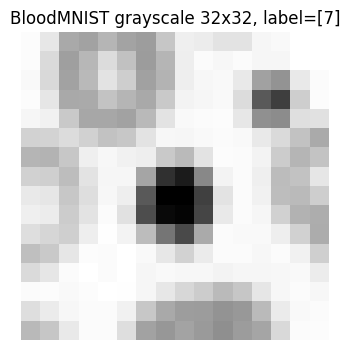

Vector length: 256
Vector norm: 1.0


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import medmnist
from medmnist import INFO
import matplotlib.pyplot as plt

data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.Grayscale(),      # RGB -> 1 channel
    transforms.Resize((16, 16)), # now actually 32x32
    transforms.ToTensor(),       # shape: [1, 32, 32]
])

train_dataset = DataClass(split='train', transform=transform, download=True)
val_dataset   = DataClass(split='val', transform=transform, download=True)
test_dataset  = DataClass(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

def image_to_quantum_vector(img_tensor):
    # img_tensor expected shape: [1, 32, 32]
    vec = img_tensor.squeeze(0).numpy().astype(np.float64).flatten()
    norm = np.linalg.norm(vec)
    if norm == 0:
        vec = np.ones_like(vec, dtype=np.float64) / np.sqrt(len(vec))
    else:
        vec = vec / norm
    return vec

img, label = train_dataset[0]

print("Image tensor shape:", img.shape)   # should be torch.Size([1, 32, 32])
print("Label:", label)
print("Min pixel:", img.min().item())
print("Max pixel:", img.max().item())

plt.figure(figsize=(4, 4))
plt.imshow(img.squeeze(0).numpy(), cmap="gray", interpolation="nearest")
plt.title(f"BloodMNIST grayscale 32x32, label={label}")
plt.axis("off")
plt.show()

vec = image_to_quantum_vector(img)
print("Vector length:", len(vec))         # should be 1024
print("Vector norm:", np.linalg.norm(vec)) # should be ~1.0

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

# get one image from your dataset
img, label = train_dataset[0]

# convert image -> normalized vector
vec = image_to_quantum_vector(img)

print("Vector length:", len(vec))
print("Norm:", np.linalg.norm(vec))

# build your butterfly state-prep circuit
qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)

#print("=== State-preparation circuit ===")
#print(qc.draw())

# inverse circuit
qc_inv = qc.inverse()

#print(qc.draw())

##print("\n=== Inverse circuit ===")
print(qc_inv.draw())


# -------------------------------------------------
# Verify the prepared state
# -------------------------------------------------
sv_prepared = Statevector.from_instruction(qc)

##print("\nPrepared state dimension:", len(sv_prepared.data))
##print("Prepared-state norm:", np.linalg.norm(sv_prepared.data))

# optional: compare to input vector
# depending on qubit ordering convention, this may or may not match exactly
##print("Direct match to vec:", np.allclose(sv_prepared.data, vec, atol=1e-8))

# -------------------------------------------------
# Verify inverse undoes the preparation
# -------------------------------------------------
full_check = QuantumCircuit(qc.num_qubits)
full_check.compose(qc, inplace=True)
full_check.compose(qc_inv, inplace=True)

sv_back = Statevector.from_instruction(full_check)

zero_state = np.zeros(2**qc.num_qubits, dtype=complex)
zero_state[0] = 1.0

##print("Returns to |0...0>:", np.allclose(sv_back.data, zero_state, atol=1e-8))

Vector length: 256
Norm: 1.0
                                                                           »
q_0: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_1: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_2: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │       ┌─────┴──────┐»
q_3: ──────o─────────────o─────────────o─────────────o───────┤ Ry(1.5154) ├»
           │             │             │       ┌─────┴──────┐└─────┬──────┘»
q_4: ──────o─────────────o─────────────o───────┤ Ry(1.5342) ├──────■───────»
           │             │       ┌─────┴──────┐└─────┬──────┘      │       »
q_5: ──────o─────────────o───────┤ Ry(1.4698) ├──────■─────────────■───────»
           │       ┌─────┴──────┐└─────┬──────┘

In [6]:
import qft

In [7]:
from qft import qft2
from qiskit import QuantumCircuit

# your inverse circuit
qc_inv = qc.inverse()

# qft2 expects qubits-per-dimension, not total qubits
half = qc_inv.num_qubits // 2

qft2_circ = qft2(half)

combined = QuantumCircuit(qc_inv.num_qubits)
combined.compose(qc_inv, inplace=True)
combined.compose(qft2_circ, inplace=True)

print(combined.draw())

                                                                           »
q_0: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_1: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_2: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │       ┌─────┴──────┐»
q_3: ──────o─────────────o─────────────o─────────────o───────┤ Ry(1.5154) ├»
           │             │             │       ┌─────┴──────┐└─────┬──────┘»
q_4: ──────o─────────────o─────────────o───────┤ Ry(1.5342) ├──────■───────»
           │             │       ┌─────┴──────┐└─────┬──────┘      │       »
q_5: ──────o─────────────o───────┤ Ry(1.4698) ├──────■─────────────■───────»
           │       ┌─────┴──────┐└─────┬──────┘      │             │       »

Vector length: 256
Vector norm: 1.0
Prep-state norm: 0.9999999999987058
Prep matches vec: True
Total qubits: 8
Qubits per dimension: 4
Image side length: 16

=== Prep + 2D QFT circuit ===
                                                                           »
q_0: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_1: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_2: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │       ┌─────┴──────┐»
q_3: ──────o─────────────o─────────────o─────────────o───────┤ Ry(1.5154) ├»
           │             │             │       ┌─────┴──────┐└─────┬──────┘»
q_4: ──────o─────────────o─────────────o───────┤ Ry(1.5342) ├──────■───────»
           │             │       ┌─────┴──

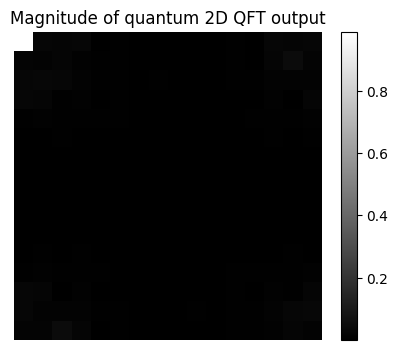

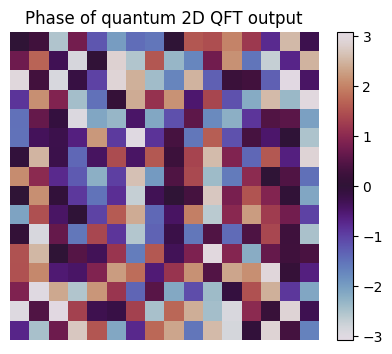


=== Comparison with classical 2D FFT ===
All close: True
Max abs error: 2.217810877178703e-14
Mean abs error: 2.2561038801443913e-15


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector

# -------------------------------------------------
# 1) Your image -> normalized quantum vector
# -------------------------------------------------
def image_to_quantum_vector(img_tensor):
    vec = img_tensor.squeeze(0).numpy().astype(np.float64).flatten()
    norm = np.linalg.norm(vec)
    if norm == 0:
        vec = np.ones_like(vec, dtype=np.float64) / np.sqrt(len(vec))
    else:
        vec = vec / norm
    return vec

img, label = train_dataset[0]
vec = image_to_quantum_vector(img)

print("Vector length:", len(vec))          # 1024
print("Vector norm:", np.linalg.norm(vec)) # ~1

# -------------------------------------------------
# 2) Build your prep circuit
#    IMPORTANT: you said qc_inv prepares your image state
# -------------------------------------------------
qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)
qc_inv = qc.inverse()

# Verify that qc_inv really prepares the image state in your convention
sv_prep = Statevector.from_instruction(qc_inv)
print("Prep-state norm:", np.linalg.norm(sv_prep.data))
print("Prep matches vec:", np.allclose(sv_prep.data, vec, atol=1e-8))

# -------------------------------------------------
# 3) Build 2D QFT circuit
#    32x32 => 5 row qubits + 5 col qubits
# -------------------------------------------------
n_row = 4
n_col = 4
n = n_row + n_col

assert qc_inv.num_qubits == 8, f"Expected 10 qubits for 32x32 image, got {qc_inv.num_qubits}"

row_qubits = list(range(n_row))
col_qubits = list(range(n_row, n))

qc_2d_qft = QuantumCircuit(n)
qc_2d_qft.compose(qc_inv, inplace=True)

# Use do_swaps=True so the output ordering is the standard QFT ordering
qc_2d_qft.compose(QFT(n_row, do_swaps=True), qubits=row_qubits, inplace=True)
qc_2d_qft.compose(QFT(n_col, do_swaps=True), qubits=col_qubits, inplace=True)

print("\n=== 2D QFT circuit ===")
print(qc_2d_qft.draw())

# -------------------------------------------------
# 4) Get state after 2D QFT
# -------------------------------------------------
sv_after_qft = Statevector.from_instruction(qc_2d_qft)
state_after_qft = sv_after_qft.data

print("\nState dimension after QFT:", len(state_after_qft))
print("State norm after QFT:", np.linalg.norm(state_after_qft))

# Reshape back into 32x32 complex array
qft_2d_quantum = state_after_qft.reshape(16, 16)

# Print a small corner of the complex matrix
print("\nTop-left 4x4 block of quantum 2D QFT result:")
print(qft_2d_quantum[:4, :4])

# -------------------------------------------------
# 5) Plot what "the thing after QFT" looks like
# -------------------------------------------------
magnitude = np.abs(qft_2d_quantum)
phase = np.angle(qft_2d_quantum)

plt.figure(figsize=(5, 4))
plt.imshow(magnitude, cmap="gray")
plt.title("Magnitude of quantum 2D QFT output")
plt.colorbar()
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(phase, cmap="twilight")
plt.title("Phase of quantum 2D QFT output")
plt.colorbar()
plt.axis("off")
plt.show()

# -------------------------------------------------
# 6) Classical reference: 2D FFT with orthonormal normalization
# -------------------------------------------------
img_2d = vec.reshape(16, 16)
qft_2d_classical = np.fft.fft2(img_2d, norm="ortho")

# -------------------------------------------------
# 7) Compare quantum result vs classical result
#    Remove global phase before comparison
# -------------------------------------------------
q = qft_2d_quantum.flatten()
c = qft_2d_classical.flatten()

# Find a stable reference entry for global phase
idx = np.argmax(np.abs(c))
if np.abs(c[idx]) > 1e-12:
    global_phase = q[idx] / c[idx]
else:
    global_phase = 1.0 + 0.0j

q_aligned = q / global_phase

max_err = np.max(np.abs(q_aligned - c))
mean_err = np.mean(np.abs(q_aligned - c))
is_close = np.allclose(q_aligned, c, atol=1e-6)

print("\n=== Comparison with classical 2D FFT ===")
print("All close:", is_close)
print("Max abs error:", max_err)
print("Mean abs error:", mean_err)

In [9]:
####fidelity of the inverse preparation state method 
from qiskit.quantum_info import Statevector, state_fidelity
import numpy as np

img, label = train_dataset[0]
vec = image_to_quantum_vector(img)

qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)

# test forward
#sv_forward = Statevector.from_instruction(qc)
#fid_forward = state_fidelity(sv_forward, vec)

# test inverse
qc_inv = qc.inverse()
sv_inverse = Statevector.from_instruction(qc_inv)
fid_inverse = state_fidelity(sv_inverse, vec)

#print("Forward fidelity:", fid_forward)
print("Inverse fidelity:", fid_inverse)
print(qc_inv)

Inverse fidelity: 0.9999999999974118
                                                                           »
q_0: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_1: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_2: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │       ┌─────┴──────┐»
q_3: ──────o─────────────o─────────────o─────────────o───────┤ Ry(1.5154) ├»
           │             │             │       ┌─────┴──────┐└─────┬──────┘»
q_4: ──────o─────────────o─────────────o───────┤ Ry(1.5342) ├──────■───────»
           │             │       ┌─────┴──────┐└─────┬──────┘      │       »
q_5: ──────o─────────────o───────┤ Ry(1.4698) ├──────■─────────────■───────»
           │       ┌─────┴──────┐└─────

Number of qubits: 8

COMPARING ⟨Z⟩ EXPECTATION VALUES

⟨Z⟩ WITHOUT QFT (prepared image state):
  Qubit 0: 0.021595
  Qubit 1: 0.054251
  Qubit 2: 0.113981
  Qubit 3: 0.252988
  Qubit 4: 0.002894
  Qubit 5: 0.021513
  Qubit 6: 0.022909
  Qubit 7: -0.010708

⟨Z⟩ WITH QFT (after applying 2D QFT):
  Qubit 0: 0.841868
  Qubit 1: 0.901527
  Qubit 2: 0.907879
  Qubit 3: 0.909151
  Qubit 4: 0.881640
  Qubit 5: 0.916186
  Qubit 6: 0.927492
  Qubit 7: 0.927887

QUANTIFYING THE WASHING OUT EFFECT

Average |⟨Z⟩| without QFT: 0.062605
Average |⟨Z⟩| with QFT:    0.901704
Reduction factor: 0.07x

Qubits with |⟨Z⟩| > 0.01 after QFT: 8/8


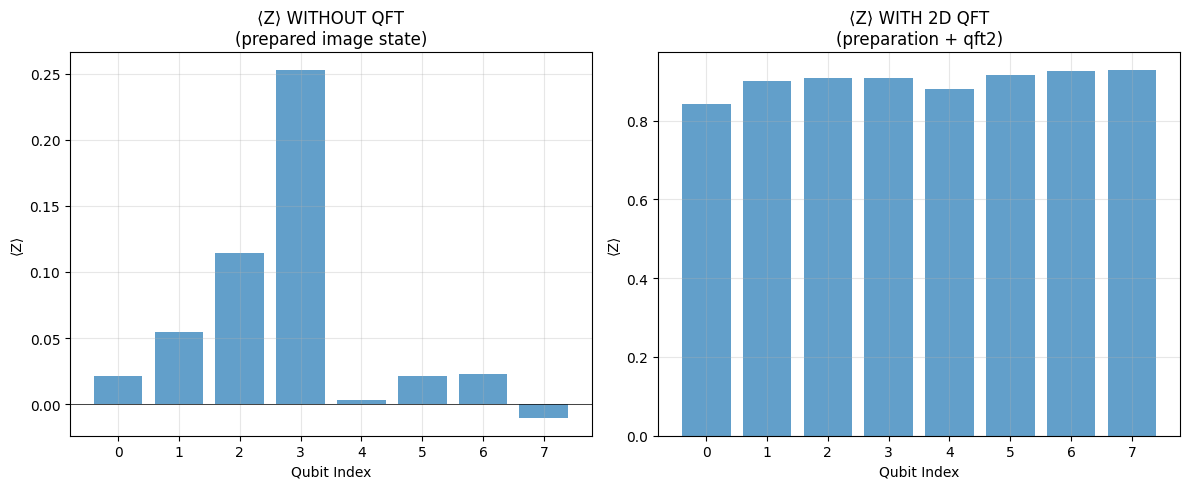


PROBABILITY DISTRIBUTION ANALYSIS

Qubit 0 probabilities WITHOUT QFT:
  P(0) = 0.510798
  P(1) = 0.489202
  ⟨Z⟩ = 0.021595

Qubit 0 probabilities WITH QFT:
  P(0) = 0.920934
  P(1) = 0.079066
  ⟨Z⟩ = 0.841868

Average qubit entropy WITHOUT QFT: 0.9926 bits
Average qubit entropy WITH QFT:    0.2802 bits
Maximum possible entropy: 1.0 bit per qubit

✓ QFT did not completely randomize the single-qubit distributions.

AMPLITUDE DISTRIBUTION (first 8 basis states)

Without QFT:
  |00000000⟩: 0.089139
  |00000001⟩: 0.088758
  |00000010⟩: 0.089520
  |00000011⟩: 0.089520
  |00000100⟩: 0.088758
  |00000101⟩: 0.089520
  |00000110⟩: 0.088377
  |00000111⟩: 0.086853

With QFT:
  |00000000⟩: 0.932960
  |00000001⟩: 0.162143
  |00000010⟩: 0.036049
  |00000011⟩: 0.023401
  |00000100⟩: 0.015760
  |00000101⟩: 0.012982
  |00000110⟩: 0.009665
  |00000111⟩: 0.007666

SUMMARY
Without QFT: |⟨Z⟩| = 0.0626
With QFT:    |⟨Z⟩| = 0.9017
Entropy without QFT: 0.993 bits
Entropy with QFT:    0.280 bits

✓ The QFT pre

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli
from qft import qft2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# -------------------------------------------------
# 1) Get one image and convert to normalized vector
# -------------------------------------------------
img, label = train_dataset[1]
vec = image_to_quantum_vector(img)

# -------------------------------------------------
# 2) Build butterfly circuit, then use its inverse
#    as the actual image-preparation circuit
# -------------------------------------------------
qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)
qc_inv = qc.inverse()

n_qubits = qc_inv.num_qubits
print(f"Number of qubits: {n_qubits}")

assert n_qubits % 2 == 0, "Need an even number of qubits for 2D QFT"
half = n_qubits // 2

# -------------------------------------------------
# 3) Build 2D QFT circuit using your library
# -------------------------------------------------
qft_circ = qft2(half)

# -------------------------------------------------
# 4) Test WITH QFT
# -------------------------------------------------
qc_qft = QuantumCircuit(n_qubits)
qc_qft.compose(qc_inv, inplace=True)    # image state preparation
qc_qft.compose(qft_circ, inplace=True)  # 2D QFT
sv_qft = Statevector.from_instruction(qc_qft)

# -------------------------------------------------
# 5) Test WITHOUT QFT
# -------------------------------------------------
qc_no_qft = QuantumCircuit(n_qubits)
qc_no_qft.compose(qc_inv, inplace=True)
sv_no_qft = Statevector.from_instruction(qc_no_qft)

# -------------------------------------------------
# 6) Compare <Z> values
# -------------------------------------------------
print("\n" + "="*60)
print("COMPARING ⟨Z⟩ EXPECTATION VALUES")
print("="*60)

print("\n⟨Z⟩ WITHOUT QFT (prepared image state):")
z_no_qft = []
for q in range(n_qubits):
    z_val = float(np.real(sv_no_qft.expectation_value(Pauli('Z'), [q])))
    z_no_qft.append(z_val)
    print(f"  Qubit {q}: {z_val:.6f}")

print("\n⟨Z⟩ WITH QFT (after applying 2D QFT):")
z_with_qft = []
for q in range(n_qubits):
    z_val = float(np.real(sv_qft.expectation_value(Pauli('Z'), [q])))
    z_with_qft.append(z_val)
    print(f"  Qubit {q}: {z_val:.6f}")

# -------------------------------------------------
# 7) Quantify "washing out"
# -------------------------------------------------
print("\n" + "="*60)
print("QUANTIFYING THE WASHING OUT EFFECT")
print("="*60)

avg_abs_no_qft = np.mean(np.abs(z_no_qft))
avg_abs_with_qft = np.mean(np.abs(z_with_qft))

print(f"\nAverage |⟨Z⟩| without QFT: {avg_abs_no_qft:.6f}")
print(f"Average |⟨Z⟩| with QFT:    {avg_abs_with_qft:.6f}")

if avg_abs_with_qft > 0:
    print(f"Reduction factor: {avg_abs_no_qft / avg_abs_with_qft:.2f}x")
else:
    print("Reduction factor: infinite (all values became zero)")

nonzero_after_qft = np.sum(np.abs(z_with_qft) > 0.01)
print(f"\nQubits with |⟨Z⟩| > 0.01 after QFT: {nonzero_after_qft}/{n_qubits}")

# -------------------------------------------------
# 8) Visualize the difference
# -------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(n_qubits), z_no_qft, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Qubit Index')
plt.ylabel('⟨Z⟩')
plt.title('⟨Z⟩ WITHOUT QFT\n(prepared image state)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(n_qubits), z_with_qft, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Qubit Index')
plt.ylabel('⟨Z⟩')
plt.title('⟨Z⟩ WITH 2D QFT\n(preparation + qft2)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 9) Single-qubit probabilities
# -------------------------------------------------
print("\n" + "="*60)
print("PROBABILITY DISTRIBUTION ANALYSIS")
print("="*60)

q0 = 0
probs_no_qft = sv_no_qft.probabilities([q0])
probs_with_qft = sv_qft.probabilities([q0])

print(f"\nQubit {q0} probabilities WITHOUT QFT:")
print(f"  P(0) = {probs_no_qft[0]:.6f}")
print(f"  P(1) = {probs_no_qft[1]:.6f}")
print(f"  ⟨Z⟩ = {probs_no_qft[0] - probs_no_qft[1]:.6f}")

print(f"\nQubit {q0} probabilities WITH QFT:")
print(f"  P(0) = {probs_with_qft[0]:.6f}")
print(f"  P(1) = {probs_with_qft[1]:.6f}")
print(f"  ⟨Z⟩ = {probs_with_qft[0] - probs_with_qft[1]:.6f}")

# -------------------------------------------------
# 10) Average qubit entropy
# -------------------------------------------------
def compute_avg_qubit_entropy(sv, n_qubits):
    total_entropy = 0.0
    for q in range(n_qubits):
        probs = sv.probabilities([q])
        probs = np.clip(probs, 1e-12, 1.0)
        total_entropy += entropy(probs, base=2)
    return total_entropy / n_qubits

entropy_no_qft = compute_avg_qubit_entropy(sv_no_qft, n_qubits)
entropy_with_qft = compute_avg_qubit_entropy(sv_qft, n_qubits)

print(f"\nAverage qubit entropy WITHOUT QFT: {entropy_no_qft:.4f} bits")
print(f"Average qubit entropy WITH QFT:    {entropy_with_qft:.4f} bits")
print("Maximum possible entropy: 1.0 bit per qubit")

if entropy_with_qft > 0.99:
    print("\n⚠️  QFT created nearly uniform single-qubit distributions.")
elif entropy_with_qft > 0.9:
    print("\n⚠️  QFT created very random single-qubit distributions.")
else:
    print("\n✓ QFT did not completely randomize the single-qubit distributions.")

# -------------------------------------------------
# 11) Show first few amplitudes
# -------------------------------------------------
print("\n" + "="*60)
print("AMPLITUDE DISTRIBUTION (first 8 basis states)")
print("="*60)

bitwidth = int(np.ceil(np.log2(len(sv_no_qft))))

print("\nWithout QFT:")
for i in range(min(8, len(sv_no_qft))):
    amp = sv_no_qft[i]
    print(f"  |{i:0{bitwidth}b}⟩: {abs(amp):.6f}")

print("\nWith QFT:")
for i in range(min(8, len(sv_qft))):
    amp = sv_qft[i]
    print(f"  |{i:0{bitwidth}b}⟩: {abs(amp):.6f}")

# -------------------------------------------------
# 12) Summary
# -------------------------------------------------
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Without QFT: |⟨Z⟩| = {avg_abs_no_qft:.4f}")
print(f"With QFT:    |⟨Z⟩| = {avg_abs_with_qft:.4f}")
print(f"Entropy without QFT: {entropy_no_qft:.3f} bits")
print(f"Entropy with QFT:    {entropy_with_qft:.3f} bits")

if avg_abs_with_qft < 0.1:
    print("\n❌ The QFT severely washed out the information in single-qubit ⟨Z⟩ readout.")
else:
    print("\n✓ The QFT preserved some information in single-qubit ⟨Z⟩ readout.")

In [11]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli
from qft import qft2
from collections import defaultdict

# ============================================================
# 1) Variational ring ansatz
#    Each layer:
#      - RY on every qubit
#      - RZ on every qubit
#      - CX ring entanglement
# ============================================================

def add_variational_ring(qc, params, n_qubits, n_layers=2):
    """
    params shape = (n_layers, 2, n_qubits)
      params[layer, 0, q] -> RY angle
      params[layer, 1, q] -> RZ angle
    """
    for layer in range(n_layers):
        # Single-qubit rotations
        for q in range(n_qubits):
            qc.ry(params[layer, 0, q], q)
            qc.rz(params[layer, 1, q], q)

        # Ring entanglement
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
        qc.cx(n_qubits - 1, 0)  # close the ring

    return qc


# ============================================================
# 2) Build full quantum feature circuit
#    prep -> 2D QFT -> variational ring
# ============================================================

def build_qml_feature_circuit(img_tensor, params, n_layers=2):
    vec = image_to_quantum_vector(img_tensor)

    # Your butterfly builder
    qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)

    # In your workflow, qc.inverse() is the actual prep circuit
    qc_inv = qc.inverse()

    n_qubits = qc_inv.num_qubits
    assert n_qubits % 2 == 0, f"Need even number of qubits for 2D QFT, got {n_qubits}"

    half = n_qubits // 2

    full = QuantumCircuit(n_qubits)

    # State preparation
    full.compose(qc_inv, inplace=True)

    # 2D QFT
    full.compose(qft2(half), inplace=True)

    # Variational block
    add_variational_ring(full, params, n_qubits=n_qubits, n_layers=n_layers)

    return full


# ============================================================
# 3) Extract all-qubit <Z> features
# ============================================================

def z_feature_vector_from_circuit(qc):
    sv = Statevector.from_instruction(qc)
    n_qubits = qc.num_qubits

    feats = []
    for q in range(n_qubits):
        z_val = sv.expectation_value(Pauli("Z"), [q])
        feats.append(float(np.real(z_val)))

    return np.array(feats, dtype=np.float64)


def quantum_features_for_image(img_tensor, params, n_layers=2):
    qc = build_qml_feature_circuit(img_tensor, params, n_layers=n_layers)
    return z_feature_vector_from_circuit(qc)


# ============================================================
# 4) Parameter initialization
# ============================================================

def init_variational_params(n_qubits, n_layers=2, scale=0.05, seed=0):
    rng = np.random.default_rng(seed)
    return rng.normal(loc=0.0, scale=scale, size=(n_layers, 2, n_qubits))


# ============================================================
# 5) Balanced subset helper
#    Start small because statevector simulation is expensive
# ============================================================

def make_balanced_subset(dataset, samples_per_class=25):
    """
    Returns a list of indices with a balanced number of samples per class.
    Assumes dataset[i] -> (img, label)
    """
    buckets = defaultdict(list)

    for idx in range(len(dataset)):
        _, label = dataset[idx]

        # handle tensor / numpy / int labels
        if hasattr(label, "item"):
            label = int(label.item())
        else:
            label = int(label)

        if len(buckets[label]) < samples_per_class:
            buckets[label].append(idx)

        # stop early if all discovered classes are full
        if len(buckets) > 0 and all(len(v) >= samples_per_class for v in buckets.values()):
            # keep scanning only until all currently seen classes are filled
            pass

    selected = []
    for label in sorted(buckets.keys()):
        selected.extend(buckets[label][:samples_per_class])

    return selected


# ============================================================
# 6) Quick smoke test on one image
# ============================================================

img, label = train_dataset[0]
vec = image_to_quantum_vector(img)

# get qubit count from your prep circuit
qc_tmp, _, _ = build_butterfly_mc_ry_circuit(vec)
n_qubits = qc_tmp.num_qubits

params = init_variational_params(n_qubits=n_qubits, n_layers=2, scale=0.20, seed=42)

qc_model = build_qml_feature_circuit(img, params, n_layers=2)
features = z_feature_vector_from_circuit(qc_model)

print("Number of qubits:", n_qubits)
print("Feature vector shape:", features.shape)
print("Z features:", np.round(features, 6))
print(qc_model.draw())

Number of qubits: 8
Feature vector shape: (8,)
Z features: [0.807935 0.820644 0.793104 0.822288 0.849145 0.853518 0.809922 0.834073]
                                                                           »
q_0: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_1: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │             │       »
q_2: ──────o─────────────o─────────────o─────────────o─────────────o───────»
           │             │             │             │       ┌─────┴──────┐»
q_3: ──────o─────────────o─────────────o─────────────o───────┤ Ry(1.5154) ├»
           │             │             │       ┌─────┴──────┐└─────┬──────┘»
q_4: ──────o─────────────o─────────────o───────┤ Ry(1.5342) ├──────■───────»
           │             │       ┌─────┴──────┐└─────┬──────┘      │       »
q_5: ──────o────────

In [12]:
# Check several samples
for i in range(10):
    img, label = train_dataset[i]
    feats = quantum_features_for_image(img, params, n_layers=2)
    print(f"sample {i:2d} | label={label} | features={np.round(feats, 4)}")

sample  0 | label=[7] | features=[0.8079 0.8206 0.7931 0.8223 0.8491 0.8535 0.8099 0.8341]
sample  1 | label=[3] | features=[0.7179 0.7895 0.8352 0.7973 0.8372 0.7899 0.8408 0.7727]
sample  2 | label=[6] | features=[0.7841 0.837  0.8227 0.8464 0.8399 0.8513 0.8409 0.8406]
sample  3 | label=[6] | features=[0.7603 0.8316 0.826  0.8385 0.8412 0.8388 0.834  0.8209]
sample  4 | label=[7] | features=[0.7934 0.842  0.8174 0.8521 0.8397 0.8752 0.8157 0.8663]
sample  5 | label=[6] | features=[0.7629 0.8363 0.8373 0.8457 0.8533 0.8543 0.8532 0.8371]
sample  6 | label=[2] | features=[0.8047 0.8538 0.8391 0.8567 0.8433 0.8692 0.8325 0.8589]
sample  7 | label=[2] | features=[0.7515 0.8376 0.8173 0.8455 0.8167 0.8636 0.8143 0.8537]
sample  8 | label=[7] | features=[0.8288 0.834  0.8105 0.8346 0.8605 0.8593 0.8339 0.8447]
sample  9 | label=[2] | features=[0.7823 0.8402 0.8254 0.843  0.8454 0.866  0.835  0.8483]


In [13]:
from qiskit.quantum_info import Pauli, Statevector
import numpy as np

def zx_features_from_circuit(qc):
    sv = Statevector.from_instruction(qc)
    n = qc.num_qubits
    
    z = [float(np.real(sv.expectation_value(Pauli("Z"), [q]))) for q in range(n)]
    x = [float(np.real(sv.expectation_value(Pauli("X"), [q]))) for q in range(n)]
    
    return np.array(z + x)   # concatenate Z + X

In [14]:
def quantum_features_zx(img_tensor, params, n_layers=2):
    qc = build_qml_feature_circuit(img_tensor, params, n_layers=n_layers)
    feats = zx_features_from_circuit(qc)
    
    # normalize
    feats = (feats - np.mean(feats)) / (np.std(feats) + 1e-8)
    
    return feats

for i in range(7):
    img, label = train_dataset[i]
    feats = quantum_features_zx(img, params, n_layers=2)
    
    print(f"sample {i}, label={label}: {np.round(feats, 3)}")

sample 0, label=[7]: [ 0.961  0.991  0.926  0.995  1.058  1.068  0.966  1.023 -0.957 -1.114
 -1.048 -1.059 -0.954 -0.972 -0.978 -0.907]
sample 1, label=[3]: [ 0.799  0.977  1.09   0.996  1.094  0.977  1.104  0.935 -0.859 -1.111
 -0.997 -1.051 -0.97  -1.038 -0.989 -0.957]
sample 2, label=[6]: [ 0.884  1.008  0.974  1.03   1.015  1.041  1.017  1.016 -0.921 -1.152
 -1.039 -1.057 -0.927 -0.971 -0.989 -0.927]
sample 3, label=[6]: [ 0.847  1.016  1.002  1.032  1.038  1.033  1.022  0.99  -0.9   -1.153
 -1.05  -1.037 -0.959 -1.019 -0.942 -0.92 ]
sample 4, label=[7]: [ 0.895  1.008  0.951  1.031  1.002  1.084  0.947  1.064 -0.922 -1.111
 -1.071 -1.062 -0.966 -1.006 -0.943 -0.902]
sample 5, label=[6]: [ 0.828  1.001  1.003  1.023  1.041  1.043  1.041  1.003 -0.934 -1.127
 -0.972 -1.057 -0.931 -1.009 -1.007 -0.947]
sample 6, label=[2]: [ 0.906  1.019  0.985  1.026  0.995  1.055  0.97   1.031 -0.905 -1.129
 -1.056 -1.044 -0.951 -1.    -0.982 -0.919]


In [ ]:
# ============================================================
# FULL HYBRID QML PIPELINE FOR BLOODMNIST
# prep -> 2D QFT -> variational ring -> Z+X readout -> classifier
# ============================================================

import numpy as np
from collections import defaultdict
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli
from qft import qft2

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 1) IMAGE -> NORMALIZED QUANTUM VECTOR
# ------------------------------------------------------------

def image_to_quantum_vector(img_tensor):
    vec = img_tensor.squeeze(0).numpy().astype(np.float64).flatten()
    norm = np.linalg.norm(vec)
    if norm == 0:
        vec = np.ones_like(vec, dtype=np.float64) / np.sqrt(len(vec))
    else:
        vec = vec / norm
    return vec


# ------------------------------------------------------------
# 2) VARIATIONAL RING ANSATZ
#    params shape = (n_layers, 2, n_qubits)
# ------------------------------------------------------------

def add_variational_ring(qc, params, n_qubits, n_layers=2):
    for layer in range(n_layers):
        for q in range(n_qubits):
            qc.ry(params[layer, 0, q], q)
            qc.rz(params[layer, 1, q], q)

        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
        qc.cx(n_qubits - 1, 0)

    return qc


# ------------------------------------------------------------
# 3) FULL QUANTUM CIRCUIT
#    prep -> 2D QFT -> variational ring
# ------------------------------------------------------------

def build_qml_feature_circuit(img_tensor, params, n_layers=2):
    vec = image_to_quantum_vector(img_tensor)

    # Your state prep builder
    qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)

    # In your workflow, qc.inverse() prepares the image state
    qc_inv = qc.inverse()

    n_qubits = qc_inv.num_qubits
    assert n_qubits % 2 == 0, f"Need even number of qubits for 2D QFT, got {n_qubits}"

    half = n_qubits // 2

    full = QuantumCircuit(n_qubits)
    full.compose(qc_inv, inplace=True)
    full.compose(qft2(half), inplace=True)
    add_variational_ring(full, params, n_qubits=n_qubits, n_layers=n_layers)

    return full


# ------------------------------------------------------------
# 4) ZX READOUT
# ------------------------------------------------------------

def zx_features_from_circuit(qc):
    sv = Statevector.from_instruction(qc)
    n = qc.num_qubits

    z = [float(np.real(sv.expectation_value(Pauli("Z"), [q]))) for q in range(n)]
    x = [float(np.real(sv.expectation_value(Pauli("X"), [q]))) for q in range(n)]

    feats = np.array(z + x, dtype=np.float64)

    # per-sample normalization
    feats = (feats - np.mean(feats)) / (np.std(feats) + 1e-8)

    return feats


def quantum_features_zx(img_tensor, params, n_layers=2):
    qc = build_qml_feature_circuit(img_tensor, params, n_layers=n_layers)
    return zx_features_from_circuit(qc)


# ------------------------------------------------------------
# 5) PARAM INITIALIZATION
# ------------------------------------------------------------

def init_variational_params(n_qubits, n_layers=2, scale=0.15, seed=42):
    rng = np.random.default_rng(seed)
    return rng.normal(loc=0.0, scale=scale, size=(n_layers, 2, n_qubits))


# ------------------------------------------------------------
# 6) LABEL HELPER
# ------------------------------------------------------------

def label_to_int(label):
    if hasattr(label, "item"):
        return int(label.item())
    if isinstance(label, (list, tuple, np.ndarray)):
        return int(label[0])
    return int(label)


# ------------------------------------------------------------
# 7) BALANCED SUBSET
# ------------------------------------------------------------

def make_balanced_subset_indices(dataset, samples_per_class=25):
    buckets = defaultdict(list)

    for idx in range(len(dataset)):
        _, label = dataset[idx]
        y = label_to_int(label)

        if len(buckets[y]) < samples_per_class:
            buckets[y].append(idx)

        # stop once every discovered class has enough
        if len(buckets) == 8 and all(len(v) >= samples_per_class for v in buckets.values()):
            break

    selected = []
    for y in sorted(buckets.keys()):
        selected.extend(buckets[y][:samples_per_class])

    return selected


# ------------------------------------------------------------
# 8) BUILD FEATURE MATRIX
# ------------------------------------------------------------

def build_feature_dataset(dataset, indices, params, n_layers=2, verbose=True):
    X = []
    y = []

    total = len(indices)
    for k, idx in enumerate(indices):
        img, label = dataset[idx]
        feats = quantum_features_zx(img, params, n_layers=n_layers)

        X.append(feats)
        y.append(label_to_int(label))

        if verbose and ((k + 1) % 20 == 0 or (k + 1) == total):
            print(f"Processed {k+1}/{total}")

    X = np.array(X, dtype=np.float64)
    y = np.array(y, dtype=np.int64)
    return X, y


# ------------------------------------------------------------
# 9) GET QUBIT COUNT FROM ONE SAMPLE
# ------------------------------------------------------------

img0, label0 = train_dataset[0]
vec0 = image_to_quantum_vector(img0)
qc_tmp, _, _ = build_butterfly_mc_ry_circuit(vec0)
n_qubits = qc_tmp.num_qubits

print("Number of qubits:", n_qubits)

# You can tune these:
N_LAYERS = 2
PARAM_SCALE = 0.20
SEED = 42

params = init_variational_params(
    n_qubits=n_qubits,
    n_layers=N_LAYERS,
    scale=PARAM_SCALE,
    seed=SEED
)

# ------------------------------------------------------------
# 10) CHOOSE SUBSET SIZES
# ------------------------------------------------------------
# Start here. Increase later now that you have more compute.

TRAIN_PER_CLASS = 400
VAL_PER_CLASS   = 200
TEST_PER_CLASS  = 200

train_idx = make_balanced_subset_indices(train_dataset, samples_per_class=TRAIN_PER_CLASS)
val_idx   = make_balanced_subset_indices(val_dataset,   samples_per_class=VAL_PER_CLASS)
test_idx  = make_balanced_subset_indices(test_dataset,  samples_per_class=TEST_PER_CLASS)

print("Train samples:", len(train_idx))
print("Val samples:  ", len(val_idx))
print("Test samples: ", len(test_idx))

# ------------------------------------------------------------
# 11) EXTRACT QUANTUM FEATURES
# ------------------------------------------------------------

print("\nExtracting TRAIN features...")
X_train, y_train = build_feature_dataset(train_dataset, train_idx, params, n_layers=N_LAYERS)

print("\nExtracting VAL features...")
X_val, y_val = build_feature_dataset(val_dataset, val_idx, params, n_layers=N_LAYERS)

print("\nExtracting TEST features...")
X_test, y_test = build_feature_dataset(test_dataset, test_idx, params, n_layers=N_LAYERS)

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

# ------------------------------------------------------------
# 12) BASELINE 1: LOGISTIC REGRESSION
# ------------------------------------------------------------

print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)

clf_lr = LogisticRegression(max_iter=2000, multi_class="auto")
clf_lr.fit(X_train, y_train)

y_train_pred_lr = clf_lr.predict(X_train)
y_val_pred_lr   = clf_lr.predict(X_val)
y_test_pred_lr  = clf_lr.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Val accuracy:  ", accuracy_score(y_val, y_val_pred_lr))
print("Test accuracy: ", accuracy_score(y_test, y_test_pred_lr))

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred_lr, digits=4))

print("Confusion matrix (test):")
print(confusion_matrix(y_test, y_test_pred_lr))

# ------------------------------------------------------------
# 13) BASELINE 2: SMALL MLP
# ------------------------------------------------------------

print("\n" + "="*60)
print("MLP CLASSIFIER")
print("="*60)

clf_mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size="auto",
    learning_rate_init=1e-3,
    max_iter=500,
    random_state=SEED
)

clf_mlp.fit(X_train, y_train)

y_train_pred_mlp = clf_mlp.predict(X_train)
y_val_pred_mlp   = clf_mlp.predict(X_val)
y_test_pred_mlp  = clf_mlp.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_train_pred_mlp))
print("Val accuracy:  ", accuracy_score(y_val, y_val_pred_mlp))
print("Test accuracy: ", accuracy_score(y_test, y_test_pred_mlp))

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred_mlp, digits=4))

print("Confusion matrix (test):")
print(confusion_matrix(y_test, y_test_pred_mlp))

# ------------------------------------------------------------
# 14) QUICK FEATURE SANITY CHECK
# ------------------------------------------------------------

print("\n" + "="*60)
print("FEATURE SANITY CHECK")
print("="*60)

print("Feature std per dimension on train:")
print(np.round(np.std(X_train, axis=0), 4))

class_means = {}
for c in sorted(np.unique(y_train)):
    class_means[c] = np.mean(X_train[y_train == c], axis=0)
    print(f"class {c}: {np.round(class_means[c], 3)}")

Number of qubits: 8
Train samples: 3200
Val samples:   1342
Test samples:  1600

Extracting TRAIN features...
Processed 20/3200
Processed 40/3200
Processed 60/3200
Processed 80/3200
Processed 100/3200
Processed 120/3200
Processed 140/3200
Processed 160/3200
Processed 180/3200
Processed 200/3200
Processed 220/3200
Processed 240/3200
Processed 260/3200
Processed 280/3200
Processed 300/3200
Processed 320/3200
Processed 340/3200
Processed 360/3200
Processed 380/3200
Processed 400/3200
Processed 420/3200
Processed 440/3200
Processed 460/3200
Processed 480/3200
Processed 500/3200
Processed 520/3200
Processed 540/3200
Processed 560/3200
Processed 580/3200
Processed 600/3200
Processed 620/3200
Processed 640/3200
Processed 660/3200
Processed 680/3200
Processed 700/3200
Processed 720/3200
Processed 740/3200
Processed 760/3200
Processed 780/3200
Processed 800/3200
Processed 820/3200
Processed 840/3200
Processed 860/3200
Processed 880/3200
Processed 900/3200
Processed 920/3200
Processed 940/3200
P

In [ ]:

"""
states = [format(i, f'0{N_QUBITS}b') for i in range(2**N_QUBITS)]
theoretical_amps = np.abs(sv.data)

table_data = {
    'Basis States': states,
    'Theoretical': theoretical_amps
}

sampled_amp_results = {}
for shots in SHOTS_LIST:
    probs = np.array([results[shots][state] for state in states])
    amps = np.sqrt(probs)
    sampled_amp_results[shots] = amps
    table_data[f'{shots} Shots'] = amps

df = pd.DataFrame(table_data)

for col in df.columns:
    if col != 'Basis States':
        df[col] = df[col].apply(lambda x: f"{x:.4e}")

print(df.to_string(index=False))

# ============================================================
# ERROR METRICS FOR AMPLITUDES
# ============================================================

amp_msre_values = []
for shots in SHOTS_LIST:
    amps = sampled_amp_results[shots]
    msre = np.mean(((amps - theoretical_amps) ** 2) / (theoretical_amps + 1e-10))
    amp_msre_values.append(msre)
    print(f"{shots} shots amplitude MSRE: {msre:.6e}")

# ============================================================
# CREATE VISUALIZATION LIKE YOUR EXAMPLE
# ============================================================

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.3])

# Left: line plot of amplitudes
ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(states, theoretical_amps, marker='o', linewidth=2, label='Theoretical')
for shots in SHOTS_LIST[:-1]:  # remove 1,000,000 if too crowded, or keep it
    ax1.plot(states, sampled_amp_results[shots], marker='o', linewidth=2, label=f'{shots} shots')

ax1.set_title('Comparison of Theoretical and Sampled Amplitudes', fontsize=18)
ax1.set_xlabel('Quantum States', fontsize=14)
ax1.set_ylabel('Amplitude', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Right: amplitude table
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')

display_df = pd.DataFrame({
    'Basis\nStates': states,
    'Theoretical': [f"{x:.4e}" for x in theoretical_amps],
    #'100 Shots': [f"{x:.4e}" for x in sampled_amp_results[100]],
    '1,000 Shots': [f"{x:.4e}" for x in sampled_amp_results[1000]],
    '10,000 Shots': [f"{x:.4e}" for x in sampled_amp_results[10000]],
    '100,000 Shots': [f"{x:.4e}" for x in sampled_amp_results[100000]],
    '1,000,000 Shots': [f"{x:.4e}" for x in sampled_amp_results[1000000]],
})

msre_row = ['MSRE', '0.0000e+00'] + [f"{x:.4e}" for x in amp_msre_values]
display_df.loc[len(display_df)] = msre_row

table = ax2.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

ax2.set_title('Table of amplitudes', fontsize=16, pad=20)

plt.tight_layout()
plt.show()
"""

'\nstates = [format(i, f\'0{N_QUBITS}b\') for i in range(2**N_QUBITS)]\ntheoretical_amps = np.abs(sv.data)\n\ntable_data = {\n    \'Basis States\': states,\n    \'Theoretical\': theoretical_amps\n}\n\nsampled_amp_results = {}\nfor shots in SHOTS_LIST:\n    probs = np.array([results[shots][state] for state in states])\n    amps = np.sqrt(probs)\n    sampled_amp_results[shots] = amps\n    table_data[f\'{shots} Shots\'] = amps\n\ndf = pd.DataFrame(table_data)\n\nfor col in df.columns:\n    if col != \'Basis States\':\n        df[col] = df[col].apply(lambda x: f"{x:.4e}")\n\nprint(df.to_string(index=False))\n\n# ============================================================\n# ERROR METRICS FOR AMPLITUDES\n# ============================================================\n\namp_msre_values = []\nfor shots in SHOTS_LIST:\n    amps = sampled_amp_results[shots]\n    msre = np.mean(((amps - theoretical_amps) ** 2) / (theoretical_amps + 1e-10))\n    amp_msre_values.append(msre)\n    print(f"{shots} 